<a href="https://colab.research.google.com/github/emilahlgren/1kb570_2026/blob/main/Labs/02_modelling_wine_quality/starter_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboration 2: Modelling Wine Quality

**Name(s):**
**Date:**

Follow `instructions.md` for the full task description, timing, and the
Checkpoint questions. This notebook is your **working notebook** — light
comments are enough here; your answers to the Checkpoints go on a
**separate answer sheet**, not in this file.

Sections below are labelled to match the instructions exactly
(Step 1 / Step 2 / Step 3 / Step 4) so you can move through the 4-hour
session without hunting for where each part goes.

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split, cross_val_score, KFold, cross_val_predict
from sklearn.metrics import (mean_squared_error, r2_score,
                              confusion_matrix, ConfusionMatrixDisplay,
                              accuracy_score)

sns.set_theme(style='ticks', palette='colorblind')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

RANDOM_STATE = 42  # keep this fixed so your results are reproducible

---
## Step 1 — Data Curation (0:00–0:30)

- [ ] Load the data, check shape / columns / dtypes
- [ ] Check for missing values
- [ ] Check for duplicate rows — look closely before deciding what to do (→ **Checkpoint 1a**)
- [ ] Look at the distribution of `quality` (→ **Checkpoint 1b**)
- [ ] Standardise the 11 predictor variables, ready for Step 2

In [4]:
# Load the data (red wine is the primary dataset for Steps 1-3)

# Download the files from github if you are working on uppmax/colab
!wget https://raw.githubusercontent.com/peterbmob/1kb570_2026/refs/heads/main/Labs/02_modelling_wine_quality/winequality-red.csv
!wget https://raw.githubusercontent.com/peterbmob/1kb570_2026/refs/heads/main/Labs/02_modelling_wine_quality/winequality-white.csv

df = pd.read_csv('winequality-red.csv', sep=';')
df.head()

--2026-09-18 06:53:47--  https://raw.githubusercontent.com/peterbmob/1kb570_2026/refs/heads/main/Labs/02_modelling_wine_quality/winequality-red.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 84199 (82K) [text/plain]
Saving to: ‘winequality-red.csv’

winequality-red.csv 100%[===================>]  82.23K  --.-KB/s    in 0.005s  

2026-09-18 06:53:47 (16.9 MB/s) - ‘winequality-red.csv’ saved [84199/84199]

--2026-09-18 06:53:48--  https://raw.githubusercontent.com/peterbmob/1kb570_2026/refs/heads/main/Labs/02_modelling_wine_quality/winequality-white.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [25]:
# TODO: check the shape, column names, and dtypes
print('Shape:', df.shape)
print('\nColumn names:', df.columns.tolist())
print('\nData types:')
df.info()

Shape: (1599, 12)

Column names: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

Data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 

In [32]:
# TODO: check for missing values
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [34]:
# TODO: check for duplicate rows (df.duplicated())
# How many are there? What will you do about them, and why?
# -- write your reasoning on the answer sheet (Checkpoint 1a), not here
df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

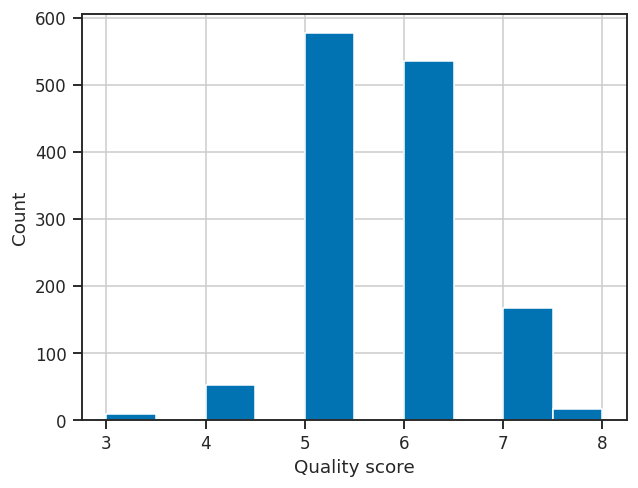

In [43]:
df['quality'].value_counts()
df['quality'].hist()
plt.xlabel('Quality score')
plt.ylabel('Count')
plt.show()

In [48]:
# TODO: separate predictors (X, the 11 physicochemical columns) from the
# response (y = quality), then standardise X ready for PCA.
# Hint: StandardScaler().fit_transform(X) -- do NOT standardise quality itself.
X = df.drop('quality', axis=1)
y = df['quality']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



---
## Step 2 — PCA (0:30–1:30)

Fit PCA on the **standardised predictors only** — `quality` is the response
you are trying to predict, not a predictor, so it must not go into the PCA.

- [ ] Fit PCA, produce a scree plot (individual + cumulative variance)
- [ ] Decide how many components to keep, and by which criterion (→ **Checkpoint 2a**)
- [ ] Score plot (PC1 vs PC2), coloured by `quality` (→ **Checkpoint 2b**)
- [ ] Loading plot for the same two components (→ **Checkpoint 2c**)

In [52]:
# TODO: fit PCA on the standardised predictor matrix
pca = PCA()
scores = pca.fit_transform(X_scaled)

Explained variance per PC:
  PC1:  28.3%  (cumulative:  28.3%)  ███████████
  PC2:  17.3%  (cumulative:  45.6%)  ██████
  PC3:  14.1%  (cumulative:  59.7%)  █████
  PC4:  11.4%  (cumulative:  71.1%)  ████
  PC5:   8.7%  (cumulative:  79.8%)  ███
  PC6:   5.8%  (cumulative:  85.6%)  ██
  PC7:   5.3%  (cumulative:  90.9%)  ██
  PC8:   3.7%  (cumulative:  94.7%)  █
  PC9:   3.1%  (cumulative:  97.8%)  █
  PC10:   1.6%  (cumulative:  99.5%)  
  PC11:   0.5%  (cumulative: 100.0%)  


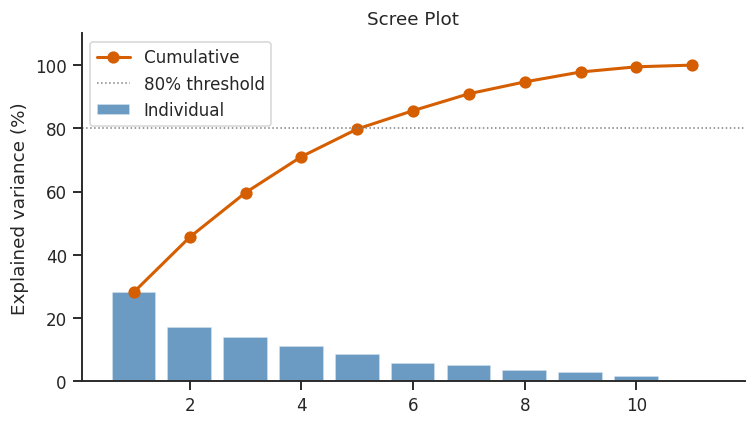

In [51]:
# TODO: scree plot -- individual explained variance (bars) and
# cumulative explained variance (line), same style as the course notebooks
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

print('Explained variance per PC:')
for i, (ev, cum) in enumerate(zip(explained, cumulative), 1):
    bar = '█' * int(ev * 40)
    print(f'  PC{i}: {ev*100:5.1f}%  (cumulative: {cum*100:5.1f}%)  {bar}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, len(explained)+1), explained*100, color='steelblue', alpha=0.8, label='Individual')
ax.plot(range(1, len(explained)+1), cumulative*100, 'ro-', lw=2, ms=7, label='Cumulative')
ax.axhline(80, color='gray', ls=':', lw=1, label='80% threshold')
ax.set_xlabel('')
ax.set_ylabel('Explained variance (%)')
ax.set_title('Scree Plot')
ax.legend()
ax.set_ylim(0, 110)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

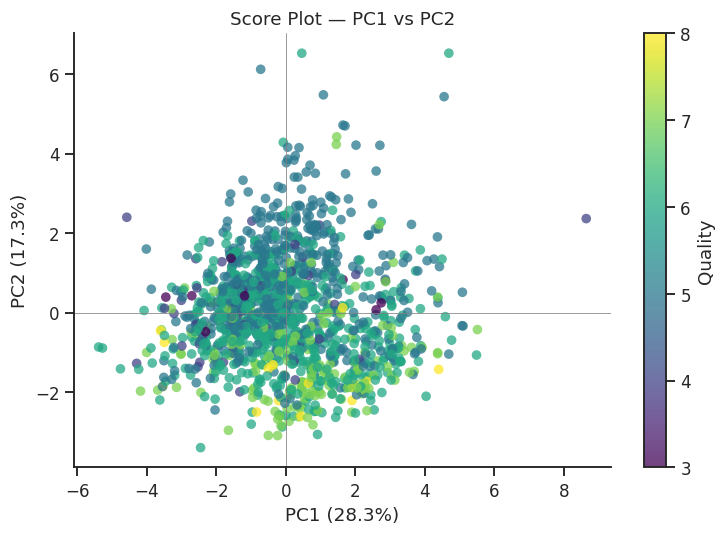

In [57]:
# TODO: score plot -- PC1 vs PC2, colour the points by `quality`
# (a continuous colourmap, e.g. cmap='viridis', works well for an ordinal 0-10 score)

fig, ax = plt.subplots(figsize=(7, 5))

# PC1 vs PC2
scatter = ax.scatter(scores[:, 0], scores[:, 1], c=y,
                   cmap='viridis', s=40, alpha=0.75, edgecolors='none')

ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
ax.set_title('Score Plot — PC1 vs PC2')
# Add a color bar
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label('Quality')

ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

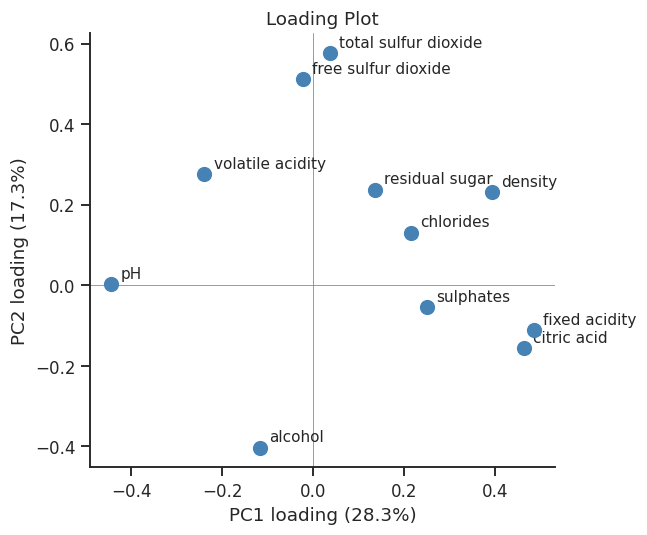

In [65]:
# TODO: loading plot for PC1 vs PC2 -- which variables have the largest
# loadings, and in which direction?
loadings = pca.components_.T   # shape (n_variables, n_components)
elements = X.columns

# Loading plot
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(loadings[:, 0], loadings[:, 1], color='steelblue', s=80, zorder=5)
for i, elem in enumerate(elements):
    ax.annotate(elem, (loadings[i, 0], loadings[i, 1]),
                textcoords='offset points', xytext=(6, 4), fontsize=10)
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
ax.set_xlabel(f'PC1 loading ({explained[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 loading ({explained[1]*100:.1f}%)')
ax.set_title('Loading Plot')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

---
## Step 3 — Model Quality: PLS *and* LDA (1:30–3:00)

Build **both** models today (see `instructions.md` for the full reasoning) —
not a choice between them. Keep both sections; do not delete either.

- [ ] Fit both models with a proper train/test split (or CV)
- [ ] Report validated performance for each, not training-set fit (→ **Checkpoints 3a, 3b**)
- [ ] Compare the two models (→ **Checkpoint 3c**)
- [ ] Identify which variable(s) matter most to each model (→ **Checkpoint 3d**)

### PLS (quality treated as continuous)

In [97]:
# TODO: train/test split (or set up cross-validation)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y,
                                                    test_size=0.2, random_state=RANDOM_STATE)

Optimal number of components: 5  (RMSECV = 0.67)


/tmp/ipykernel_3146/3151377295.py:31: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  ax1.legend(lines1+labels2, labels1+labels2, fontsize=9)


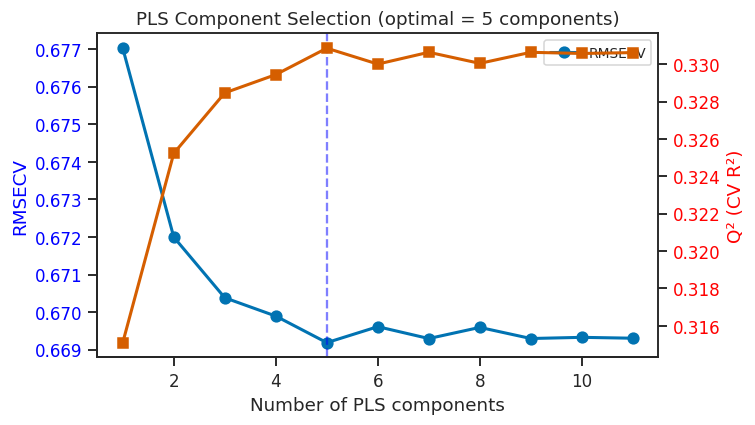

PLSRegression(n_components=np.int64(5))

In [110]:
# TODO: fit PLSRegression; choose the number of latent variables using
# cross-validated RMSE or Q^2, not the training-set fit alone


max_comp = X_train.shape[1]
rmsecv = []
q2     = []
kf = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

for nc in range(1, max_comp + 1):
    pls_tmp = PLSRegression(n_components=nc, scale=False)
    y_pred = cross_val_predict(pls_tmp, X_train, y_train, cv=kf).ravel()
    rmsecv.append(np.sqrt(mean_squared_error(y_train, y_pred)))
    q2.append(r2_score(y_train, y_pred))

opt_nc = np.argmin(rmsecv) + 1
print(f'Optimal number of components: {opt_nc}  (RMSECV = {rmsecv[opt_nc-1]:.2f})')

fig, ax1 = plt.subplots(figsize=(7, 4))
ax2 = ax1.twinx()
ax1.plot(range(1, max_comp+1), rmsecv, 'bo-', lw=2, ms=7, label='RMSECV')
ax1.axvline(opt_nc, color='blue', ls='--', alpha=0.5)
ax2.plot(range(1, max_comp+1), q2, 'rs-', lw=2, ms=7, label='Q²')
ax1.set_xlabel('Number of PLS components')
ax1.set_ylabel('RMSECV', color='blue')
ax2.set_ylabel('Q² (CV R²)', color='red')
ax1.tick_params(axis='y', labelcolor='blue')
ax2.tick_params(axis='y', labelcolor='red')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+labels2, labels1+labels2, fontsize=9)
ax1.set_title(f'PLS Component Selection (optimal = {opt_nc} components)')
sns.despine(ax=ax1)
plt.tight_layout()
plt.show()

# Fit the PLS model with the optimal number of components using X_train and y_train
pls_model = PLSRegression(n_components=opt_nc)
pls_model.fit(X_train, y_train)

Test-set RMSE: 0.65
Test-set R²: 0.40


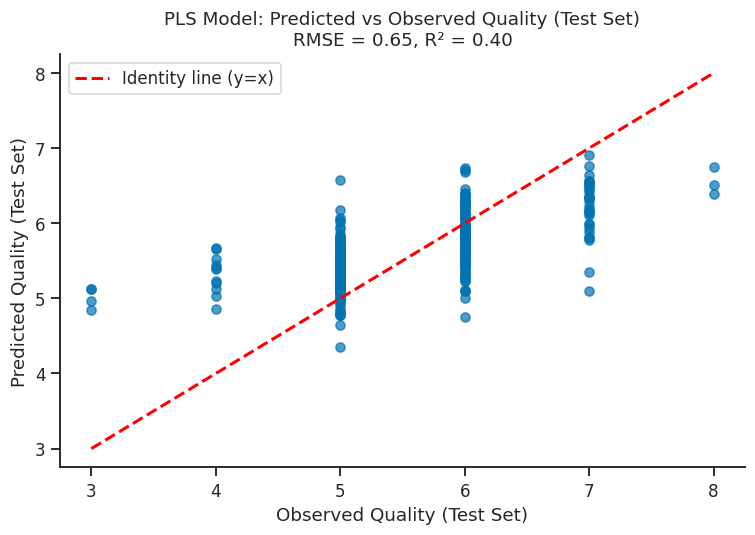

In [112]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.cross_decomposition import PLSRegression

# NOTE: pls_model is assumed to be already fitted on X_train, y_train
# from a previous cell/execution (e.g., when determining optimal components or training data evaluation).

# Make predictions on the test set using the already fitted pls_model
y_pred_test = pls_model.predict(X_test).ravel()

# Calculate RMSE and R^2 for the test set
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)

print(f'Test-set RMSE: {rmse_test:.2f}')
print(f'Test-set R²: {r2_test:.2f}')

# Predicted vs Observed plot for the test set
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test, y_pred_test, alpha=0.7)
# Use the actual min/max of y_test for the identity line
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
ax.plot([min_val, max_val], [min_val, max_val],
        '--', color='red', lw=2, label='Identity line (y=x)')
ax.set_xlabel('Observed Quality (Test Set)')
ax.set_ylabel('Predicted Quality (Test Set)')
ax.set_title(f'PLS Model: Predicted vs Observed Quality (Test Set)\nRMSE = {rmse_test:.2f}, R² = {r2_test:.2f}')
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

R²      (Calibration) = 0.3520
Q²      (Cross-val)   = 0.3333
RMSECV         = 0.67


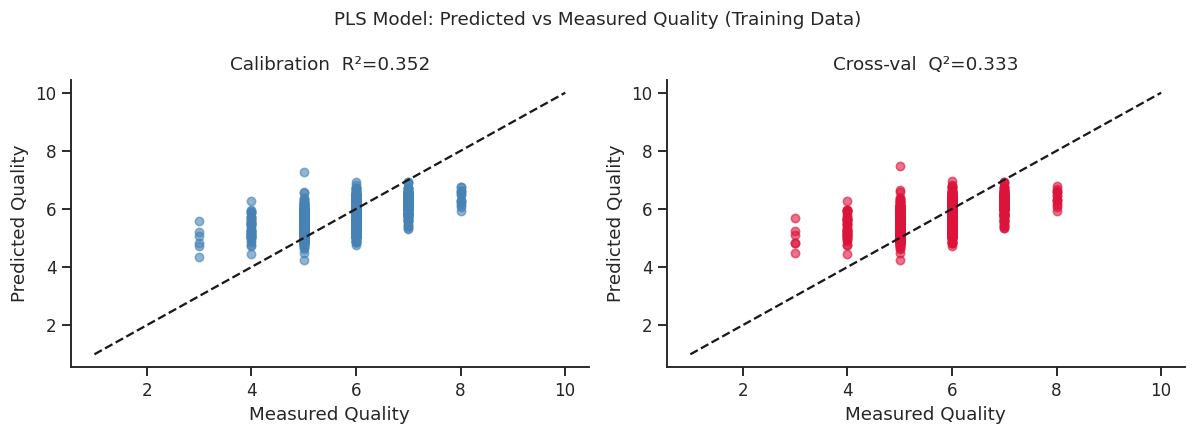

### LDA (quality binned into categories)

In [17]:
# TODO: define your quality bins explicitly here (e.g. low / medium / high).
# State your bin edges and reasoning on the answer sheet (Checkpoint 3b) --
# this is a real modelling decision, not a formality.
# Check the resulting class sizes: are they balanced?

In [18]:
# TODO: train/test split, then fit LinearDiscriminantAnalysis

In [19]:
# TODO: report a confusion matrix (ConfusionMatrixDisplay) and per-class
# accuracy on the TEST set -- accuracy alone is not enough here

In [20]:
# TODO: Checkpoint 3c/3d groundwork -- pull out and compare the top
# variables from both models (PLS coefficients vs. LDA discriminant
# loadings). Your written comparison goes on the answer sheet.

---
## Step 4 — Does It Transfer? White Wine (3:00–3:45)

Repeat the analysis on `winequality-white.csv` and check whether your
Step 2/3 findings are genuine wine chemistry or specific to the red-wine
dataset. You only need to redo **one** of PLS/LDA here, not both.

- [ ] Curate the white wine data the same way as Step 1 (its own duplicate/quality-distribution answer will differ from red)
- [ ] Redo the PCA from Step 2 on white wine (→ **Checkpoint 4a**)
- [ ] Redo ONE of your two Step 3 models on white wine (→ **Checkpoint 4b**)

In [21]:
# TODO: load winequality-white.csv, curate it the same way as Step 1
# (missing values, duplicates, quality distribution)

In [22]:
# TODO: standardise the white-wine predictors and redo the PCA + scree/
# score/loading plots from Step 2. Compare PC1's top-loading variables to
# what you found for red wine (Checkpoint 2c) -- write the comparison on
# the answer sheet (Checkpoint 4a).

In [23]:
# TODO: redo ONE of your two Step 3 models (PLS or LDA -- your choice) on
# white wine, same methodology as before. Compare validated performance and
# top variables to your red-wine result (Checkpoint 3a/3b/3d) -- write the
# comparison on the answer sheet (Checkpoint 4b).

---
## Wrap-up (3:45–4:00)

- [ ] Finalise your answer sheet (Checkpoints 1a–4b)

Hand in **this notebook** + your **answer sheet** — no separate report.